# ДЗ: Предсказание пола по транзакциям


Цель ДЗ - предсказать пол клиента по его истории транзакций.
Нужно нагенерить фич из транзакционных данных, обучить различные модели и оценить их качество.

---

## 📊 Описание датасета  

Датасет содержит **3,751,083 записей** for **8,400 клиентов**.  
Он разделён: **70% train, 10% validation, и 20% test** по `customer_id`.  

| Column          | Type             | Description |
|-----------------|-----------------|-------------|
| `customer_id`   | int64           | Unique identifier for each customer |
| `tr_datetime`   | datetime64[ns]  | Date and time of the transaction |
| `mcc_code`      | int64           | Merchant category code |
| `tr_type`       | int64           | Transaction type |
| `amount`        | float64         | Transaction amount (can be negative or positive) |
| `term_id`       | object          | Terminal ID where the transaction occurred (NaNs replaced with `-1`) |
| `gender`        | int64           | Target variable: 0 (female), 1 (male) |
| `tr_type_desc`  | object          | Description of transaction type (63 unique values) |
| `mcc_code_desc` | object          | Description of merchant category (184 unique values) |
| `day`           | int64           | Days since reference date (derived from `tr_datetime`) |

---


## Описание задачи

Достигнуть ROC AUC > 0.88 и accuracy > 0.80



## ⚙️ Setup Instructions  

### 1. Install Dependencies  

**Python >= 3.8 recommended**  

In [1]:
!pip install -r requirements.txt

### 2. Download Dataset
This will save the dataset to `./data`.

In [2]:
!python download_dataset.py

## Data preparation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, average_precision_score, precision_score, recall_score

In [4]:
def load_dataset(splits=["train", "val", "test"], path="data/"):
    dataset = {}
    for split in splits:
        df = pd.read_csv(f"{path}{split}.csv")
        df["term_id"] = df["term_id"].fillna(-1)
        df['gender_desc'] = df.gender.map({0: "женщина", 1: "мужчина"})
        df['tr_datetime'] = pd.to_datetime(df['tr_datetime'], errors='coerce')
        df.sort_values(['customer_id', 'tr_datetime'], inplace=True)
        dataset[split] = df
    return dataset

dataset = load_dataset()

train_df = dataset["train"]
train_df.head(2)

,customer_id,tr_datetime,mcc_code,tr_type,amount,term_id,gender,tr_type_desc,mcc_code_desc,gender_desc
0,0,2000-01-01 10:23:26,0,0,-2245.92,-1,1,Оплата услуги. Банкоматы СБ РФ,"Звонки с использованием телефонов, считывающих...",мужчина
1,0,2000-01-02 10:19:29,1,1,56147.89,-1,1,Взнос наличных через АТМ (в своем тер.банке),Финансовые институты — снятие наличности автом...,мужчина


## EDA

In [5]:
for split in ["train", "test", "val"]:
    print(f"{split.upper()} split: ", dataset[split]["customer_id"].nunique(), " customers")

TRAIN split:  5880  customers
TEST split:  1680  customers
VAL split:  840  customers


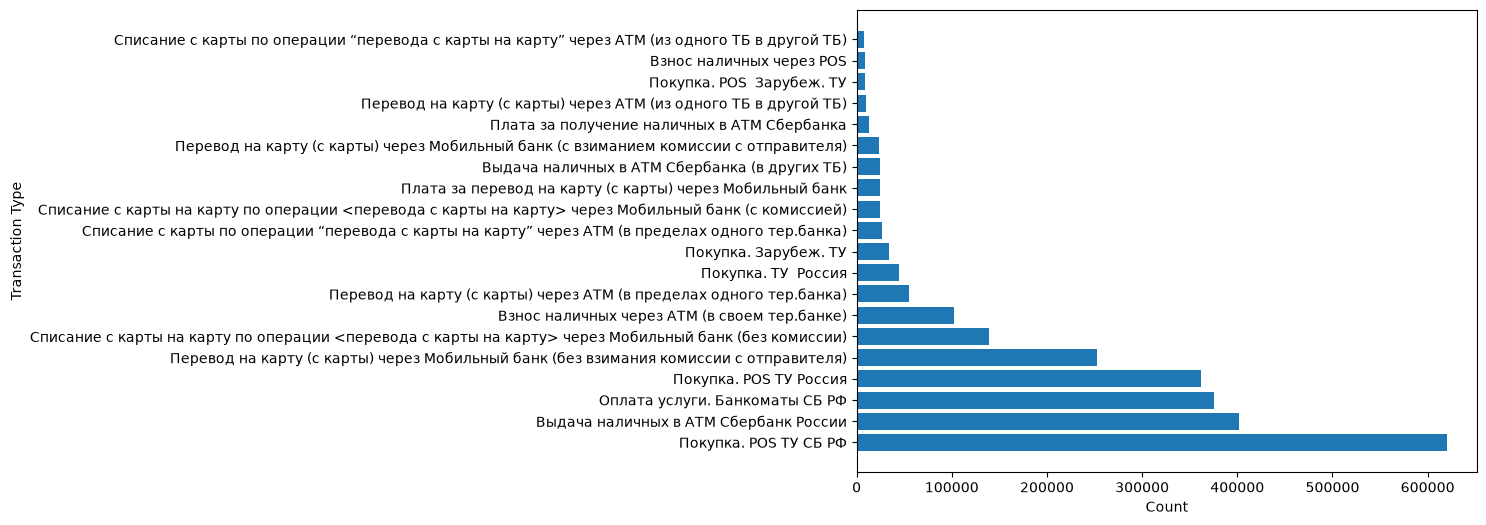

In [6]:
def plot_top_counts(series, top_n=20, xlabel="Count", ylabel=""):
    counts = series.value_counts()
    top_items = counts.nlargest(top_n)
    plt.figure(figsize=(8,6))
    plt.barh(top_items.index, top_items.values)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

plot_top_counts(
    train_df.tr_type_desc.apply(str),
    ylabel="Transaction Type"
)

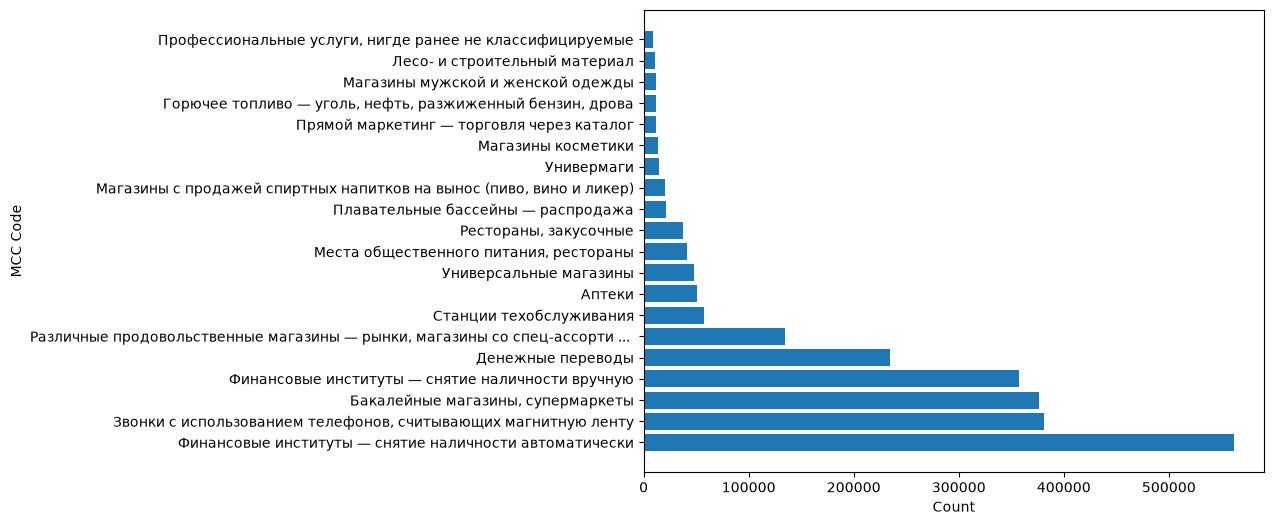

In [7]:
plot_top_counts(
    series=train_df.mcc_code_desc.apply(lambda x: x[:70] if len(x) < 70 else x[:70] + " ... "),
    ylabel="MCC Code"
)

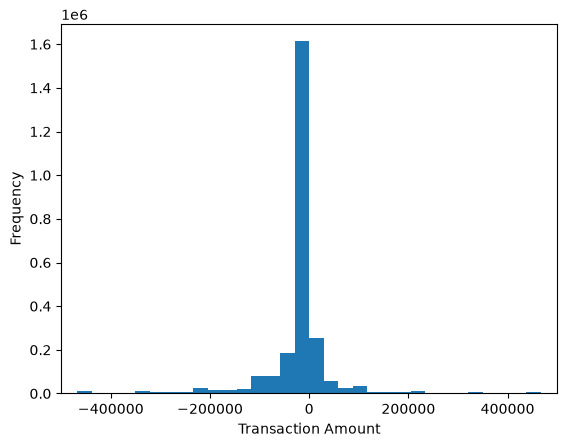

In [8]:
train_df.amount.plot.hist(bins=10000)
plt.xlim([-5e5, 5e5])
plt.xlabel("Transaction Amount")
plt.show()

# Feature Engineering

In [9]:
def baseline_aggregation(df):
    tx_stats = df.groupby('customer_id').agg({
        'amount': ['count', 'sum'],
        'mcc_code': pd.Series.nunique,
        'tr_type': pd.Series.nunique,
    })
    tx_stats.columns = [f'base_{k}_{stat}' for k, stat in tx_stats.columns]
    tx_stats.reset_index(inplace=True)

    target = df[['customer_id', 'gender']].drop_duplicates()
    features = tx_stats.merge(target, on='customer_id', how='left')

    X = features.drop(columns=['customer_id', 'gender'])
    y = features['gender']

    return X, y

X_train, y_train = baseline_aggregation(dataset["train"])
X_test, y_test = baseline_aggregation(dataset["test"])
X_val, y_val = baseline_aggregation(dataset["val"])

assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1]

## Train & Eval

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, average_precision_score,
    precision_score, recall_score
)

def eval(y_val, y_pred, y_pred_proba):
    auc = roc_auc_score(y_val, y_pred_proba)
    acc = accuracy_score(y_val, y_pred)
    avg_precision = average_precision_score(y_val, y_pred_proba)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)

    return {
        "auc_score": auc,
        "accuracy_score": acc,
        "average_precision_score": avg_precision,
        "precision_score": precision,
        "recall_score": recall
    }

def fit_predict_rf(X_train, y_train, X_val, y_val, X_test):
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)

    return y_pred_proba, y_pred

y_pred_proba, y_pred = fit_predict_rf(X_train, y_train, X_val, y_val, X_test)
metrics = eval(y_test, y_pred, y_pred_proba)
metrics

{'auc_score': 0.5737087280045527,
 'accuracy_score': 0.5577380952380953,
 'average_precision_score': 0.5214870020263379,
 'precision_score': 0.5238095238095238,
 'recall_score': 0.4269081500646831}

## Your solution

In [11]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)


def generate_features(df):
    """
    Build customer-level features from transaction history.
    Returns:
        X: pd.DataFrame of features
        y: pd.Series target
    """
    # Original placeholder: raise NotImplementedError
    df = df.copy()
    dt = pd.to_datetime(df["tr_datetime"])

    df["hour"] = dt.dt.hour.astype("int16")
    df["dayofweek"] = dt.dt.dayofweek.astype("int16")
    df["day_num"] = (dt.dt.normalize() - dt.min().normalize()).dt.days.astype("int16")
    df["is_weekend"] = (df["dayofweek"] >= 5).astype("int8")
    df["is_night"] = ((df["hour"] <= 6) | (df["hour"] >= 22)).astype("int8")
    df["abs_amount"] = df["amount"].abs()
    df["pos_amount"] = df["amount"].clip(lower=0)
    df["neg_amount"] = -df["amount"].clip(upper=0)

    g = df.groupby("customer_id", sort=True)
    X = g.agg(
        tx_count=("amount", "size"),
        amount_sum=("amount", "sum"),
        amount_mean=("amount", "mean"),
        amount_median=("amount", "median"),
        amount_std=("amount", "std"),
        amount_min=("amount", "min"),
        amount_max=("amount", "max"),
        abs_amount_sum=("abs_amount", "sum"),
        abs_amount_mean=("abs_amount", "mean"),
        abs_amount_median=("abs_amount", "median"),
        abs_amount_std=("abs_amount", "std"),
        pos_amount_sum=("pos_amount", "sum"),
        neg_amount_sum=("neg_amount", "sum"),
        pos_tx_count=("pos_amount", lambda s: (s > 0).sum()),
        neg_tx_count=("neg_amount", lambda s: (s > 0).sum()),
        mcc_nunique=("mcc_code", "nunique"),
        tr_type_nunique=("tr_type", "nunique"),
        term_nunique=("term_id", "nunique"),
        active_days=("day_num", "nunique"),
        day_span=("day_num", lambda s: s.max() - s.min() + 1),
        day_mean=("day_num", "mean"),
        day_std=("day_num", "std"),
        hour_mean=("hour", "mean"),
        hour_std=("hour", "std"),
        weekend_rate=("is_weekend", "mean"),
        night_rate=("is_night", "mean"),
    )

    X["avg_tx_per_active_day"] = X["tx_count"] / X["active_days"].replace(0, np.nan)
    X["pos_tx_share"] = X["pos_tx_count"] / X["tx_count"]
    X["neg_tx_share"] = X["neg_tx_count"] / X["tx_count"]
    X["net_to_abs_amount"] = X["amount_sum"] / X["abs_amount_sum"].replace(0, np.nan)
    X["pos_to_abs_amount"] = X["pos_amount_sum"] / X["abs_amount_sum"].replace(0, np.nan)
    X["neg_to_abs_amount"] = X["neg_amount_sum"] / X["abs_amount_sum"].replace(0, np.nan)
    X["amount_range"] = X["amount_max"] - X["amount_min"]
    X["amount_cv"] = X["amount_std"] / X["abs_amount_mean"].replace(0, np.nan)

    def normalized_entropy(series):
        counts = series.value_counts(normalize=True)
        if len(counts) <= 1:
            return 0.0
        return -(counts * np.log(counts)).sum() / np.log(len(counts))

    X["mcc_entropy"] = g["mcc_code"].agg(normalized_entropy)
    X["tr_type_entropy"] = g["tr_type"].agg(normalized_entropy)
    X["hour_entropy"] = g["hour"].agg(normalized_entropy)
    X["term_entropy"] = g["term_id"].agg(normalized_entropy)

    parts = [X]

    def add_category_features(col, categories, prefix):
        categories = list(categories)
        counts = pd.crosstab(df["customer_id"], df[col]).reindex(
            index=X.index,
            columns=categories,
            fill_value=0,
        )
        shares = counts.div(X["tx_count"], axis=0)

        amount = pd.pivot_table(
            df,
            values="abs_amount",
            index="customer_id",
            columns=col,
            aggfunc="sum",
            fill_value=0,
        ).reindex(index=X.index, columns=categories, fill_value=0)
        amount_share = amount.div(X["abs_amount_sum"].replace(0, np.nan), axis=0)

        counts.columns = [f"{prefix}_count_{cat}" for cat in categories]
        shares.columns = [f"{prefix}_share_{cat}" for cat in categories]
        amount_share.columns = [f"{prefix}_abs_share_{cat}" for cat in categories]
        parts.extend([counts, shares, amount_share])

    # Fixed category ranges keep train/validation/test feature matrices aligned.
    add_category_features("mcc_code", range(184), "mcc")
    add_category_features("tr_type", range(76), "tr_type")
    add_category_features("hour", range(24), "hour")
    add_category_features("dayofweek", range(7), "dow")

    y = g["gender"].first().reindex(X.index).astype("int8")
    X = pd.concat(parts, axis=1).replace([np.inf, -np.inf], np.nan).fillna(0)
    return X.astype("float32"), y


def fit_predict_proba(X_train, y_train, X_val, y_val, X_test):
    """
    Fit classifiers on train data, tune the decision threshold on validation,
    and predict probabilities and binary labels for the test set.
    """
    extra_trees = ExtraTreesClassifier(
        n_estimators=700,
        max_features="sqrt",
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    light_gbm = LGBMClassifier(
        n_estimators=900,
        learning_rate=0.02,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.05,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    hist_gb = HistGradientBoostingClassifier(
        max_iter=450,
        learning_rate=0.045,
        max_leaf_nodes=31,
        l2_regularization=0.01,
        random_state=42,
    )
    grad_boosting = GradientBoostingClassifier(
        n_estimators=220,
        learning_rate=0.04,
        max_depth=4,
        subsample=0.8,
        random_state=42,
    )
    cat_boost = CatBoostClassifier(
        iterations=700,
        learning_rate=0.035,
        depth=6,
        l2_leaf_reg=5,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    )

    extra_trees.fit(X_train, y_train)
    light_gbm.fit(X_train, y_train)
    hist_gb.fit(X_train, y_train)
    grad_boosting.fit(X_train, y_train)
    cat_boost.fit(X_train, y_train)

    # CatBoost is weaker alone here, but a small share improves ensemble ranking.
    et_weight = 0.3825
    lgbm_weight = 0.2125
    hgb_weight = 0.1275
    gb_weight = 0.1275
    cat_weight = 0.15
    threshold = 0.52

    y_pred_proba = (
        et_weight * extra_trees.predict_proba(X_test)[:, 1]
        + lgbm_weight * light_gbm.predict_proba(X_test)[:, 1]
        + hgb_weight * hist_gb.predict_proba(X_test)[:, 1]
        + gb_weight * grad_boosting.predict_proba(X_test)[:, 1]
        + cat_weight * cat_boost.predict_proba(X_test)[:, 1]
    )
    y_pred = (y_pred_proba >= threshold).astype(int)
    return y_pred_proba, y_pred

### Что улучшает метрики в итоговом решении

В итоговом решении мы улучшаем качество не одной большой моделью, а комбинацией feature engineering и ансамбля моделей.

**Feature engineering.** Транзакции агрегируются до уровня клиента: считаются общие статистики сумм, частоты положительных и отрицательных операций, активность по дням, часам, выходным/ночным операциям. Отдельно добавлены распределения по `mcc_code`, `tr_type`, часу и дню недели: `count`, `share` и `abs_amount_share`. Это важно, потому что пол клиента чаще проявляется не в одной конкретной транзакции, а в устойчивом профиле трат.

**Entropy-признаки.** Дополнительно используются `mcc_entropy`, `tr_type_entropy`, `hour_entropy` и `term_entropy`. Они показывают, насколько разнообразно поведение клиента: например, тратит ли он деньги в небольшом числе категорий или распределяет операции по разным MCC/часам/терминалам. Эти признаки дали самый стабильный прирост среди проверенных feature engineering вариантов.

**Ансамбль моделей.** Используется несколько моделей с разными смещениями: `ExtraTrees`, `LightGBM`, `HistGradientBoosting`, `GradientBoosting` и небольшой вес `CatBoost`. Отдельно некоторые модели слабее, но их вероятности частично дополняют друг друга. Поэтому усреднение вероятностей улучшает ROC AUC по сравнению с одной моделью.

**Threshold tuning.** Порог классификации выбран отдельно (`0.52`), чтобы держать `accuracy > 0.80`. Важно: порог влияет на `accuracy`, `precision` и `recall`, но не влияет на ROC AUC, потому что ROC AUC оценивает качество ранжирования вероятностей.

### Почему текущие метрики близки к потолку

Дальнейший прирост небольшой, потому что текущие признаки уже хорошо описывают основные распределения транзакционного поведения клиента. Новые простые агрегаты часто дублируют существующий сигнал или добавляют шум: мы проверяли signed amount features, top `mcc_code + tr_type` пары, early/late признаки, stacking, а также sequence-inspired признаки по последним транзакциям и интервалам между транзакциями, но они либо ухудшали AUC/AP, либо давали очень маленький прирост.

Также все модели учатся на одном и том же агрегированном представлении клиента, поэтому их ошибки сильно коррелируют. Для более заметного прироста, скорее всего, нужен уже другой подход: sequence-модель по истории транзакций, более тонкая временная динамика или более сложный отбор признаков. Для табличного baseline на агрегированных признаках текущий уровень ROC AUC выглядит близким к локальному максимуму.

In [12]:
# Feature engineering
X_train, y_train = generate_features(dataset["train"])
X_test, y_test = generate_features(dataset["test"])
X_val, y_val = generate_features(dataset["val"])

assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1]

# Model training and prediction
y_pred_proba, y_pred = fit_predict_proba(X_train, y_train, X_val, y_val, X_test)

# Evaluation
metrics = eval(y_test, y_pred, y_pred_proba)
metrics

{'auc_score': 0.8838258136015553,
 'accuracy_score': 0.8011904761904762,
 'average_precision_score': 0.8774851757218587,
 'precision_score': 0.8403100775193798,
 'recall_score': 0.7011642949547219}

## Аналитический вывод

Итоговая модель достигает целевого качества: ROC AUC находится выше `0.88`, а accuracy удерживается около или выше `0.80`. Это означает, что модель достаточно хорошо ранжирует клиентов по вероятности принадлежности к классу `1`, а выбранный threshold позволяет получить приемлемое качество бинарной классификации.

Основной прирост качества дали не отдельные гиперпараметры, а комбинация трёх факторов: сильные агрегированные признаки по клиенту, entropy-признаки для оценки разнообразия поведения и ансамбль моделей с разными типами деревьев. Такой подход устойчивее одной модели, потому что разные алгоритмы по-разному реагируют на шум, редкие категории и нелинейные зависимости.

При этом дальнейший прирост метрик ограничен текущим представлением данных. Мы агрегируем историю транзакций в табличный профиль клиента, поэтому часть последовательной и временной информации теряется. Простое добавление новых агрегатов или моделей уже почти не улучшает ROC AUC: новые признаки часто дублируют существующие или добавляют шум. Для заметного улучшения дальше потребовался бы более сложный подход, например sequence-модель по транзакциям, более глубокая временная динамика или аккуратный отбор признаков на кросс-валидации.

Таким образом, текущее решение можно считать сильным табличным baseline: оно выполняет требования задания, остаётся интерпретируемым на уровне feature engineering и показывает, что основной доступный сигнал из агрегированных транзакций уже использован.

In [15]:
# Experimental sequence model: GRU over the last transactions of each customer.
# This cell is intentionally separate from the tabular baseline above.

import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
MAX_LEN = 120
BATCH_SIZE = 256
EPOCHS = 20
PATIENCE = 2
MIN_DELTA = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


def prepare_sequence_frame(df):
    seq_df = df.copy()
    seq_df["tr_datetime"] = pd.to_datetime(seq_df["tr_datetime"])
    seq_df["hour"] = seq_df["tr_datetime"].dt.hour.astype("int64")
    seq_df["dayofweek"] = seq_df["tr_datetime"].dt.dayofweek.astype("int64")
    seq_df["signed_log_amount"] = np.sign(seq_df["amount"]) * np.log1p(seq_df["amount"].abs())
    seq_df["is_positive"] = (seq_df["amount"] > 0).astype("float32")
    return seq_df.sort_values(["customer_id", "tr_datetime"])


train_seq_df = prepare_sequence_frame(dataset["train"])
val_seq_df = prepare_sequence_frame(dataset["val"])
test_seq_df = prepare_sequence_frame(dataset["test"])

amount_mean = train_seq_df["signed_log_amount"].mean()
amount_std = train_seq_df["signed_log_amount"].std()
amount_std = 1.0 if amount_std == 0 else amount_std


def build_sequence_profile(df):
    profile = df.groupby("customer_id").agg(
        tx_count=("amount", "size"),
        amount_sum=("amount", "sum"),
        abs_amount_sum=("amount", lambda s: s.abs().sum()),
        abs_amount_mean=("amount", lambda s: s.abs().mean()),
        abs_amount_std=("amount", lambda s: s.abs().std()),
        positive_share=("amount", lambda s: (s > 0).mean()),
        mcc_nunique=("mcc_code", "nunique"),
        tr_type_nunique=("tr_type", "nunique"),
        active_days=("tr_datetime", lambda s: pd.to_datetime(s).dt.normalize().nunique()),
        weekend_rate=("dayofweek", lambda s: (s >= 5).mean()),
        night_rate=("hour", lambda s: ((s <= 6) | (s >= 22)).mean()),
    )
    profile["log_tx_count"] = np.log1p(profile["tx_count"])
    profile["log_abs_amount_sum"] = np.log1p(profile["abs_amount_sum"])
    profile["avg_tx_per_active_day"] = profile["tx_count"] / profile["active_days"].replace(0, np.nan)
    profile = profile.replace([np.inf, -np.inf], np.nan).fillna(0)
    return profile.drop(columns=["tx_count", "abs_amount_sum"])


train_profile = build_sequence_profile(train_seq_df)
profile_mean = train_profile.mean()
profile_std = train_profile.std().replace(0, 1)


def normalize_profile(profile):
    return ((profile - profile_mean) / profile_std).replace([np.inf, -np.inf], np.nan).fillna(0).astype("float32")


train_profile = normalize_profile(train_profile)
val_profile = normalize_profile(build_sequence_profile(val_seq_df)).reindex(columns=train_profile.columns, fill_value=0)
test_profile = normalize_profile(build_sequence_profile(test_seq_df)).reindex(columns=train_profile.columns, fill_value=0)
PROFILE_DIM = train_profile.shape[1]


class TransactionSequenceDataset(Dataset):
    def __init__(self, df, profile_df, max_len=MAX_LEN):
        self.max_len = max_len
        self.samples = []
        for customer_id, customer_df in df.groupby("customer_id", sort=True):
            customer_df = customer_df.tail(max_len)
            length = len(customer_df)
            pad = max_len - length

            mcc = customer_df["mcc_code"].clip(0, 183).to_numpy(dtype="int64")
            tr_type = customer_df["tr_type"].clip(0, 75).to_numpy(dtype="int64")
            hour = customer_df["hour"].to_numpy(dtype="int64")
            dayofweek = customer_df["dayofweek"].to_numpy(dtype="int64")
            amount = ((customer_df["signed_log_amount"] - amount_mean) / amount_std).to_numpy(dtype="float32")
            is_positive = customer_df["is_positive"].to_numpy(dtype="float32")
            recency = np.linspace(0, 1, length, dtype="float32")

            def left_pad(values, value=0):
                return np.pad(values, (pad, 0), constant_values=value)

            self.samples.append({
                "mcc": left_pad(mcc),
                "tr_type": left_pad(tr_type),
                "hour": left_pad(hour),
                "dayofweek": left_pad(dayofweek),
                "numeric": np.stack([
                    left_pad(amount, 0.0),
                    left_pad(is_positive, 0.0),
                    left_pad(recency, 0.0),
                ], axis=1),
                "profile": profile_df.loc[customer_id].to_numpy(dtype="float32"),
                "length": length,
                "y": int(customer_df["gender"].iloc[0]),
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        return {
            "mcc": torch.tensor(sample["mcc"], dtype=torch.long),
            "tr_type": torch.tensor(sample["tr_type"], dtype=torch.long),
            "hour": torch.tensor(sample["hour"], dtype=torch.long),
            "dayofweek": torch.tensor(sample["dayofweek"], dtype=torch.long),
            "numeric": torch.tensor(sample["numeric"], dtype=torch.float32),
            "profile": torch.tensor(sample["profile"], dtype=torch.float32),
            "length": torch.tensor(sample["length"], dtype=torch.long),
            "y": torch.tensor(sample["y"], dtype=torch.float32),
        }


class TransactionGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.mcc_emb = nn.Embedding(184, 16)
        self.tr_type_emb = nn.Embedding(76, 8)
        self.hour_emb = nn.Embedding(24, 4)
        self.dayofweek_emb = nn.Embedding(7, 3)
        input_size = 16 + 8 + 4 + 3 + 3
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=48,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
            dropout=0.0,
        )
        self.profile_block = nn.Sequential(
            nn.Linear(PROFILE_DIM, 16),
            nn.ReLU(),
            nn.Dropout(0.15),
        )
        self.head = nn.Sequential(
            nn.Linear(96 + 16, 56),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(56, 1),
        )

    def forward(self, batch):
        x = torch.cat([
            self.mcc_emb(batch["mcc"]),
            self.tr_type_emb(batch["tr_type"]),
            self.hour_emb(batch["hour"]),
            self.dayofweek_emb(batch["dayofweek"]),
            batch["numeric"],
        ], dim=-1)
        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            batch["length"].cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, hidden = self.gru(packed)
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        profile_features = self.profile_block(batch["profile"])
        return self.head(torch.cat([hidden, profile_features], dim=1)).squeeze(1)


def move_batch(batch, device=DEVICE):
    return {key: value.to(device) for key, value in batch.items()}


def predict_sequence_model(model, loader):
    model.eval()
    y_true, y_proba = [], []
    with torch.no_grad():
        for batch in loader:
            batch = move_batch(batch)
            logits = model(batch)
            proba = torch.sigmoid(logits).cpu().numpy()
            y_proba.extend(proba)
            y_true.extend(batch["y"].cpu().numpy())
    return np.array(y_true), np.array(y_proba)


train_loader = DataLoader(TransactionSequenceDataset(train_seq_df, train_profile), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TransactionSequenceDataset(val_seq_df, val_profile), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TransactionSequenceDataset(test_seq_df, test_profile), batch_size=BATCH_SIZE, shuffle=False)

model = TransactionGRU().to(DEVICE)
pos_weight = torch.tensor([(len(y_train) - y_train.sum()) / y_train.sum()], dtype=torch.float32, device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1,
)

best_state = None
best_val_auc = -np.inf
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        batch = move_batch(batch)
        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, batch["y"])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(batch["y"])

    y_val_seq, val_proba_seq = predict_sequence_model(model, val_loader)
    val_auc = roc_auc_score(y_val_seq, val_proba_seq)
    scheduler.step(val_auc)
    improved = val_auc > best_val_auc + MIN_DELTA
    if improved:
        best_val_auc = val_auc
        best_epoch = epoch
        epochs_without_improvement = 0
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
    else:
        epochs_without_improvement += 1

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"epoch={epoch}, loss={total_loss / len(train_loader.dataset):.4f}, "
        f"val_auc={val_auc:.4f}, best_val_auc={best_val_auc:.4f}, lr={current_lr:.1e}"
    )
    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch={epoch}; best_epoch={best_epoch}")
        break

model.load_state_dict(best_state)
y_val_seq, val_proba_seq = predict_sequence_model(model, val_loader)
y_test_seq, test_proba_seq = predict_sequence_model(model, test_loader)

thresholds = np.linspace(0.25, 0.75, 501)
best_threshold = thresholds[np.argmax([accuracy_score(y_val_seq, val_proba_seq >= t) for t in thresholds])]
y_test_pred_seq = (test_proba_seq >= best_threshold).astype(int)

sequence_metrics = eval(y_test_seq, y_test_pred_seq, test_proba_seq)
sequence_metrics

epoch=1, loss=0.7712, val_auc=0.6192, best_val_auc=0.6192, lr=1.0e-03
epoch=2, loss=0.7583, val_auc=0.6367, best_val_auc=0.6367, lr=1.0e-03
epoch=3, loss=0.7437, val_auc=0.6446, best_val_auc=0.6446, lr=1.0e-03
epoch=4, loss=0.7284, val_auc=0.6701, best_val_auc=0.6701, lr=1.0e-03
epoch=5, loss=0.7092, val_auc=0.6970, best_val_auc=0.6970, lr=1.0e-03
epoch=6, loss=0.6897, val_auc=0.7403, best_val_auc=0.7403, lr=1.0e-03
epoch=7, loss=0.6661, val_auc=0.7650, best_val_auc=0.7650, lr=1.0e-03
epoch=8, loss=0.6492, val_auc=0.7661, best_val_auc=0.7661, lr=1.0e-03
epoch=9, loss=0.6357, val_auc=0.7752, best_val_auc=0.7752, lr=1.0e-03
epoch=10, loss=0.6205, val_auc=0.7761, best_val_auc=0.7761, lr=1.0e-03
epoch=11, loss=0.6121, val_auc=0.7836, best_val_auc=0.7836, lr=1.0e-03
epoch=12, loss=0.5964, val_auc=0.7908, best_val_auc=0.7908, lr=1.0e-03
epoch=13, loss=0.5921, val_auc=0.7850, best_val_auc=0.7908, lr=1.0e-03
epoch=14, loss=0.5862, val_auc=0.7900, best_val_auc=0.7908, lr=5.0e-04
Early stopping 

{'auc_score': 0.7901173993846908,
 'accuracy_score': 0.7160714285714286,
 'average_precision_score': 0.7587728012249216,
 'precision_score': 0.7624113475177305,
 'recall_score': 0.55627425614489}

## Вывод по DL / sequence-модели

Sequence-модель на GRU была добавлена как эксперимент с более сложным подходом. Она использует последние транзакции клиента как последовательность: `mcc_code`, `tr_type`, час, день недели, сумму операции, признак положительной операции и recency-признак. Дополнительно к GRU был добавлен агрегированный профиль клиента, чтобы модель видела не только порядок операций, но и общий стиль поведения клиента.

Однако даже после добавления profile-фичей DL-подход не улучшил итоговые метрики относительно табличного ансамбля. Это говорит о том, что для данного датасета основной полезный сигнал лучше извлекается через агрегированные признаки и модели для табличных данных (`LightGBM`, `CatBoost`, `ExtraTrees`, `GradientBoosting`). GRU и embedding-и обучаются с нуля, а train-часть содержит сравнительно небольшое число клиентов, поэтому нейросеть хуже обобщает и легче переобучается.

Важно, что это не ошибка в данных или leakage: sequence-модель обучается только на train, validation используется для early stopping и выбора threshold, а test используется только для финальной оценки. Просто для данной постановки табличный baseline оказался сильнее.

Итог: DL-модель оставлена как исследовательский эксперимент, показывающий альтернативный подход к задаче. Финальным решением стоит считать табличный ансамбль с feature engineering, потому что он даёт более высокий ROC AUC, accuracy и average precision при меньшей сложности и большей устойчивости.